In [5]:
print("Ibrahim-24BAD035")
!pip install tensorflow

Ibrahim-24BAD035


# **Part A : Dataset Preparation**

In [6]:
import kagglehub
import tensorflow as tf
import os

# 1. Download Cats vs Dogs dataset from Kaggle
path = kagglehub.dataset_download("tongpython/cat-and-dog")

print("Dataset downloaded to:", path)

IMAGE_EXTS = (".jpg", ".jpeg", ".png", ".bmp")

def find_class_folder_root(base_path):
    """
    Automatically locates the directory containing
    the cat and dog class folders.
    """
    for root, dirs, files_list in os.walk(base_path):
        subdirs = [d for d in dirs if not d.startswith(".")]

        # Look for folders containing cats and dogs
        lower_dirs = [d.lower() for d in subdirs]

        if "cats" in lower_dirs and "dogs" in lower_dirs:
            return root

        # Also handle singular folder names
        if "cat" in lower_dirs and "dog" in lower_dirs:
            return root

    return base_path


data_dir = find_class_folder_root(path)

class_folders = [
    d for d in os.listdir(data_dir)
    if os.path.isdir(os.path.join(data_dir, d))
]

print("Using data_dir:", data_dir)
print("Detected classes:", len(class_folders))
print("Classes:", class_folders)

Using Colab cache for faster access to the 'cat-and-dog' dataset.
Dataset downloaded to: /kaggle/input/cat-and-dog
Using data_dir: /kaggle/input/cat-and-dog/test_set/test_set
Detected classes: 2
Classes: ['dogs', 'cats']


In [7]:
# 2. Load and preprocess images
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.3, subset="training", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir, validation_split=0.3, subset="validation", seed=42,
    image_size=IMG_SIZE, batch_size=BATCH_SIZE)

print("Class names:", train_ds.class_names)
class_names = train_ds.class_names   # saved now — lost after .prefetch() below

# 3. Split validation set further into val/test
val_batches = tf.data.experimental.cardinality(val_ds)
test_ds = val_ds.take(val_batches // 2)
val_ds = val_ds.skip(val_batches // 2)

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

Found 2023 files belonging to 2 classes.
Using 1417 files for training.
Found 2023 files belonging to 2 classes.
Using 606 files for validation.
Class names: ['cats', 'dogs']


# **Part B: Implementing Transfer Learning**

In [8]:
from tensorflow.keras.applications import ResNet50
from tensorflow.keras import layers, models

# Load pre-trained ResNet-50 without the top classification layer
base_model = ResNet50(weights="imagenet", include_top=False, input_shape=(224, 224, 3))

# Freeze the feature extraction layers
base_model.trainable = False

# Replace the final classification layer for our dataset's classes
num_classes = len(class_names)   # derived from the food dataset's folders (saved earlier)
inputs = tf.keras.Input(shape=(224, 224, 3))
x = tf.keras.applications.resnet50.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(num_classes, activation="softmax")(x)
model = models.Model(inputs, outputs)

# Compile the model
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])
model.summary()

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item (GetItem)  │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_1          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ get_item_2          │ (None, 224, 224)  │          0 │ input_layer_1[0]… │
│ (GetItem)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ stack (Stack)       │ (None, 224, 224,  │          0 │ get_item[0][0],   │
│                     │ 3)                │            │ get_item_1[0][0], │
│                     │                   │            │ get_item_2[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 224, 224,  │          0 │ stack[0][0]       │
│                     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ resnet50            │ (None, 7, 7,      │ 23,587,712 │ add[0][0]         │
│ (Functional)        │ 2048)             │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ global_average_poo… │ (None, 2048)      │          0 │ resnet50[0][0]    │
│ (GlobalAveragePool… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout (Dropout)   │ (None, 2048)      │          0 │ global_average_p… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense (Dense)       │ (None, 2)         │      4,098 │ dropout[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 23,591,810 (90.00 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 23,587,712 (89.98 MB)

## **Part C: Model Training and Performance Evaluation**

In [9]:
EPOCHS = 10
history = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS)

Epoch 1/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 373s 8s/step - accuracy: 0.9068 - loss: 0.2450 - val_accuracy: 0.9874 - val_loss: 0.0533
Epoch 2/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 361s 8s/step - accuracy: 0.9838 - loss: 0.0555 - val_accuracy: 0.9874 - val_loss: 0.0382
Epoch 3/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 319s 7s/step - accuracy: 0.9887 - loss: 0.0388 - val_accuracy: 0.9843 - val_loss: 0.0481
Epoch 4/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 315s 7s/step - accuracy: 0.9894 - loss: 0.0382 - val_accuracy: 0.9969 - val_loss: 0.0186
Epoch 5/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 320s 7s/step - accuracy: 0.9936 - loss: 0.0264 - val_accuracy: 0.9874 - val_loss: 0.0331
Epoch 6/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 323s 7s/step - accuracy: 0.9944 - loss: 0.0196 - val_accuracy: 0.9874 - val_loss: 0.0379
Epoch 7/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 321s 7s/step - accuracy: 0.9929 - loss: 0.0233 - val_accuracy: 0.9906 - val_loss: 0.0190
Epoch 8/10
45/45 ━━━━━━━━━━━━━━━━━━━━ 336s 8s/step - accuracy: 0.9965 - loss: 0.0173 - val_accuracy: 0.9906 - v

In [10]:
# Record per-epoch training/validation accuracy and loss
for i in range(EPOCHS):
    print(
        f"Epoch {i+1} - "
        f"train_acc: {history.history['accuracy'][i]:.4f}, "
        f"val_acc: {history.history['val_accuracy'][i]:.4f}, "
        f"train_loss: {history.history['loss'][i]:.4f}, "
        f"val_loss: {history.history['val_loss'][i]:.4f}"
    )

Epoch 1 - train_acc: 0.9068, val_acc: 0.9874, train_loss: 0.2450, val_loss: 0.0533
Epoch 2 - train_acc: 0.9838, val_acc: 0.9874, train_loss: 0.0555, val_loss: 0.0382
Epoch 3 - train_acc: 0.9887, val_acc: 0.9843, train_loss: 0.0388, val_loss: 0.0481
Epoch 4 - train_acc: 0.9894, val_acc: 0.9969, train_loss: 0.0382, val_loss: 0.0186
Epoch 5 - train_acc: 0.9936, val_acc: 0.9874, train_loss: 0.0264, val_loss: 0.0331
Epoch 6 - train_acc: 0.9944, val_acc: 0.9874, train_loss: 0.0196, val_loss: 0.0379
Epoch 7 - train_acc: 0.9929, val_acc: 0.9906, train_loss: 0.0233, val_loss: 0.0190
Epoch 8 - train_acc: 0.9965, val_acc: 0.9906, train_loss: 0.0173, val_loss: 0.0232
Epoch 9 - train_acc: 0.9986, val_acc: 0.9937, train_loss: 0.0106, val_loss: 0.0321
Epoch 10 - train_acc: 0.9979, val_acc: 0.9969, train_loss: 0.0128, val_loss: 0.0199


In [11]:
# Record test accuracy/loss
test_loss, test_acc = model.evaluate(test_ds)
print("Test accuracy:", test_acc)
print("Test loss:", test_loss)

9/9 ━━━━━━━━━━━━━━━━━━━━ 53s 6s/step - accuracy: 0.9896 - loss: 0.0262
Test accuracy: 0.9895833134651184
Test loss: 0.02617015689611435


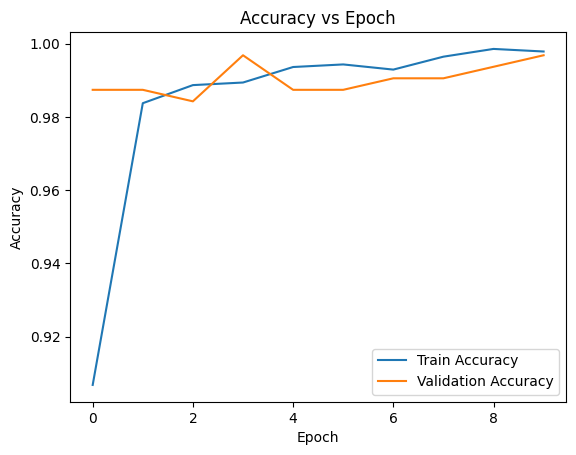

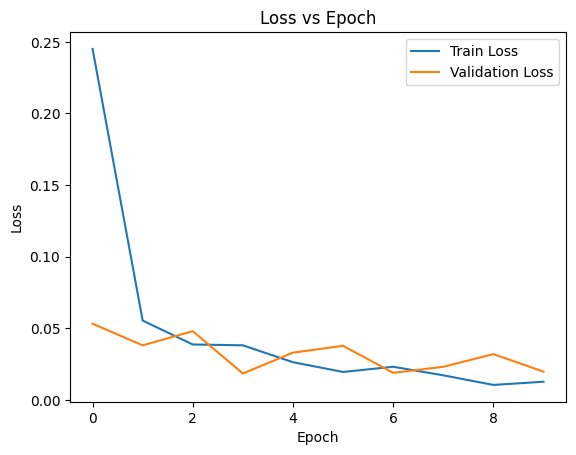

In [12]:
import matplotlib.pyplot as plt

# Accuracy vs Epoch
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epoch"); plt.ylabel("Accuracy"); plt.legend(); plt.title("Accuracy vs Epoch")
plt.show()

# Loss vs Epoch
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.legend(); plt.title("Loss vs Epoch")
plt.show()

## **Part D: Using Hugging Face Pre-Trained Models**

In [13]:
from transformers import AutoImageProcessor, AutoModelForImageClassification
import torch
from PIL import Image

# Load a pre-trained vision model from Hugging Face (ViT), trained on
# the full 1000-class ImageNet set — NOT fine-tuned on our food classes
processor = AutoImageProcessor.from_pretrained("google/vit-base-patch16-224")
hf_model = AutoModelForImageClassification.from_pretrained("google/vit-base-patch16-224")

preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  346MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

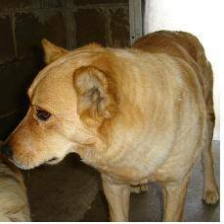

True label: dogs
ResNet50 (fine-tuned) prediction: dogs
Hugging Face ViT prediction: dingo, warrigal, warragal, Canis dingo
--------------------------------------------------


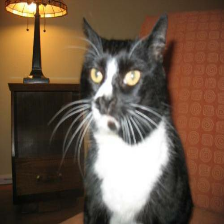

True label: cats
ResNet50 (fine-tuned) prediction: cats
Hugging Face ViT prediction: Egyptian cat
--------------------------------------------------


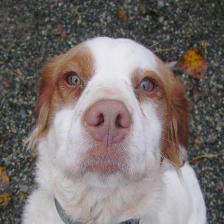

True label: dogs
ResNet50 (fine-tuned) prediction: dogs
Hugging Face ViT prediction: Brittany spaniel
--------------------------------------------------


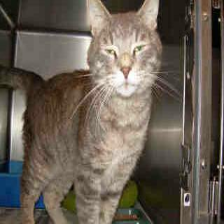

True label: cats
ResNet50 (fine-tuned) prediction: cats
Hugging Face ViT prediction: tabby, tabby cat
--------------------------------------------------


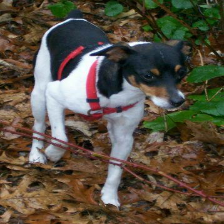

True label: dogs
ResNet50 (fine-tuned) prediction: dogs
Hugging Face ViT prediction: toy terrier
--------------------------------------------------


In [14]:
# Perform image classification on several sample images from the test
# set, and compare against the fine-tuned ResNet50 transfer learning
# model's predictions on the same images
sample_ds = test_ds.unbatch().take(5)

for img_tensor, label in sample_ds:
    img_array = img_tensor.numpy().astype("uint8")
    pil_img = Image.fromarray(img_array)
    true_class = class_names[label.numpy()]

    # --- Fine-tuned ResNet50 transfer learning model ---
    input_arr = tf.expand_dims(img_tensor, axis=0)
    my_pred = model.predict(input_arr, verbose=0)
    my_class = class_names[tf.argmax(my_pred[0]).numpy()]

    # --- Hugging Face ViT (general ImageNet) model ---
    hf_inputs = processor(images=pil_img, return_tensors="pt")
    with torch.no_grad():
        hf_logits = hf_model(**hf_inputs).logits
    hf_class = hf_model.config.id2label[hf_logits.argmax(-1).item()]

    display(pil_img)
    print("True label:", true_class)
    print("ResNet50 (fine-tuned) prediction:", my_class)
    print("Hugging Face ViT prediction:", hf_class)
    print("-" * 50)